In [1]:
%load_ext autoreload
%autoreload 2

***
# 511 keV background estimation

**Objective**


This notebook follows the COSIpy line-background tutorial. It constructs a data-driven background estimate from measured-energy sidebands, generates several spatially filtered variants, and prepares them for validation against the simulated DC4 total background.


***
## Setup

### Imports

In [2]:
# Setting the root path for the imports
from pathlib import Path
import sys

working_dir=Path.cwd()
repo_root = (
    working_dir.parent 
    if working_dir.name =='notebooks' 
    else working_dir
    )
if str(repo_root) not in sys.path: sys.path.insert(0,str(repo_root))

In [3]:

import numpy as np
import cosipy as cp
import matplotlib.pyplot as plt



from cosipy.util import fetch_wasabi_file
from astropy.io import fits
import astropy.units as u

import healpy as hp


%matplotlib inline

### Paths to input products

In [4]:
# Input products: paths used in this analysis. See `workflow/src/path_to_files.py`.
from src import path_to_files as paths
from src.binning_config import write_custom_binning_yaml

# Save every figure with an energy-binning tag for reproducibility.
plot_output_dir = paths.plot_dir_out
plot_output_dir.mkdir(parents=True, exist_ok=True)
background_binning_tag = "em480_560keV"

def save_background_figure(figure, name):
    figure.savefig(
        plot_output_dir / f"{name}_{background_binning_tag}.png",
        dpi=200,
        bbox_inches="tight",
    )

### Downloading the simulated background 

In [5]:
# Download the simulated DC4 total background used for validation.
simulated_background_remote_path = paths.simulated_background_remote_path
simulated_background_path = paths.simulated_background_path


if not simulated_background_path.exists():
    fetch_wasabi_file(
        simulated_background_remote_path,
        output=simulated_background_path,
    )
else:
    print(
        "Background file already exists:",
        simulated_background_path,
    )

Background file already exists: /Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz


## Data-driven background estimation

The  workflow used here has four stages:

1. Inspect the measured-energy spectrum around 511 keV.
2. Re-bin the weekly events with fine measured-energy bins.
3. Fit a spectral background model outside the source-dominated region.
4. Use energy sidebands to generate spatial background templates in `Phi` and `PsiChi`.

The resulting templates will later be compared with the simulated DC4 total background before one is selected for imaging.

### Inspect the measured-energy spectrum

In [6]:
# Inspect the FITS files with fits.open.
with fits.open(paths.weekly_paths[1]) as hdul:
        print(hdul.info())
        print(hdul[1].columns.names)
        

Filename: /Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/dc4_mock_dataset_week_1_unbinned_data_filtered_with_SAAcut.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     45   13829698R x 11C   [D, D, 2D, 2D, 2D, D, D, D, D, D, D]   
None
['Energies', 'TimeTags', 'Xpointings (glon,glat)', 'Ypointings (glon,glat)', 'Zpointings (glon,glat)', 'Phi', 'Chi local', 'Psi local', 'Distance', 'Chi galactic', 'Psi galactic']


In [7]:
# Select events between 450 and 600 keV from every week.

# Initialize the energy spectrum per week
selected_energies_by_week = []

# Extract the measured energies around the 511 keV feature.
# This will be done for each week 
for week, input_path in paths.weekly_paths.items():
    with fits.open(input_path) as hdul:
        energies = hdul[1].data["Energies"]

        # Applying mask for energy of interest (450, 600)
        energy_mask = (
            (energies >= 450) 
            & (energies <= 600)
        )

        selected_energies = np.asarray (
            energies[energy_mask]
        )

    selected_energies_by_week.append(selected_energies)
    print(week, selected_energies.size)


1 1198205
2 1207013
3 1215053
4 1219214
5 1224807
6 1225702
7 1230531
8 1230480
9 1219659
10 1202723
11 1204123
12 1205023
13 1203211
14 232490


In [8]:
# Define 1 keV bin edges to convert the selected events into an energy spectrum.
# These edges define the histogram bins.
energy_bin_edges = np.arange(450, 601, 1, dtype=float)

In [9]:
# Initialize the combined energy spectrum

energy_counts_all = np.zeros(
    len(energy_bin_edges) - 1,
    dtype=int,
)

# Build and combine the energy spectrum from all weeks 
for week_energies in selected_energies_by_week:
    week_counts, _ = np.histogram(
        week_energies,
        bins=energy_bin_edges
    )
    energy_counts_all += week_counts

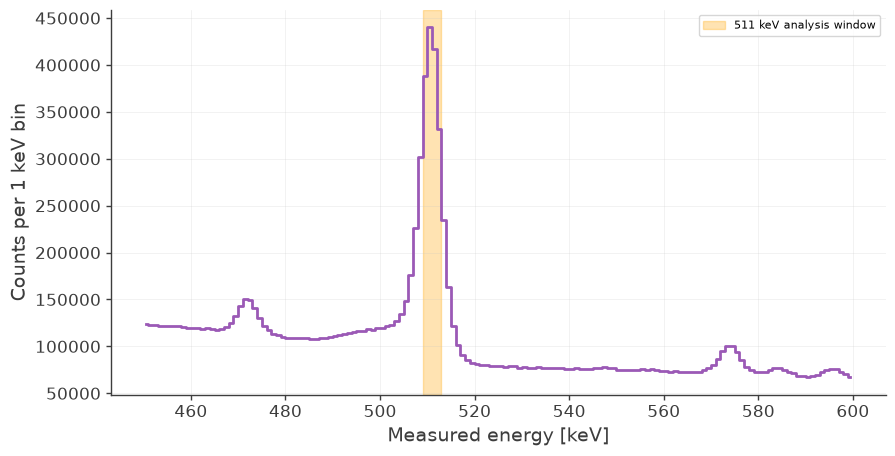

In [10]:
# Calculate the center of each energy bin
energy_bin_centers = 0.5 * (
    energy_bin_edges[:-1] + energy_bin_edges[1:]
)

    # Plot the combined energy spectrum
plt.figure(figsize=(10, 5))
plt.step(
    energy_bin_centers,
    energy_counts_all,
    where="mid",
)

# Highlight the 511 keV analysis window
plt.axvspan(
    509,
    513,
    color="orange",
    alpha=0.3,
    label="511 keV analysis window",
)

plt.xlabel("Measured energy [keV]")
plt.ylabel("Counts per 1 keV bin")
plt.legend()
plt.grid(alpha=0.3)

save_background_figure(
    plt.gcf(),
    "observed_energy_spectrum_450_600",
)


In [11]:
# Select the region around the 511 keV feature
# zoom_mask = (
#     (energy_bin_centers >= 450)
#     & (energy_bin_centers <= 560)
# )

# # Plot a closer view of the 511 keV feature
# plt.figure(figsize=(10, 5))
# plt.step(
#     energy_bin_centers,
#     energy_counts_all,
#     where="mid",
# )

# # Highlight the final 511 keV analysis window
# plt.axvspan(
#     509,
#     513,
#     color="orange",
#     alpha=0.3,
#     label="511 keV analysis window",
# )

# plt.xlabel("Measured energy [keV]")
# plt.ylabel("Counts per 1 keV bin")
# plt.legend()
# plt.grid(alpha=0.3)
# save_background_figure(
#     plt.gcf(),
#     "observed_energy_spectrum_zoom",
# )
# plt.show()

### Fine-energy binning for background estimation

In [12]:
# define the fine energy bins for the background-estimation product 
background_energy_bin_edges = np.arange(
    450,
    601,
    1,
    dtype=float,
)
# checking the auxiliarity energy binning
print('Number of bins:', len(background_energy_bin_edges) - 1)
print('Energy range', background_energy_bin_edges[[0,-1]])

Number of bins: 150
Energy range [450. 600.]


In [13]:
background_yaml_path = paths.config_511_background_path

# Create the background-binning YAML configuration if it does not exist.
# This configuration is used below to bin the weekly data.

if not background_yaml_path.exists():
    write_custom_binning_yaml(
        base_yaml_path=paths.config_511_path,
        output_yaml_path=background_yaml_path,
        energy_bins= background_energy_bin_edges
    )
    print("Background YAML file for binning was created in:",  background_yaml_path)
else:
    print("Background YAML file for binning already exists:", background_yaml_path)

Background YAML file for binning already exists: /Users/maura/Documents/COSI/data-challenge-4/workflow/config/dataio_511_background.yaml


In [14]:
# Create and load the auxiliary background products for all weeks.
background_analysis = {}


# Bin the data files for every week.
for week, input_path in paths.weekly_paths.items():
    # Path and filename prefix for the desired output.
    output_prefix = (
        paths.data_dir_out
        / f"dc4_week_{week}_511_background_binned"
    )
    output_path = output_prefix.with_suffix(".hdf5")


    # Create the weekly BinnedData object.
    background_analysis[week] = cp.BinnedData(
        background_yaml_path
    )

    # Bin the weekly events only if the output is missing.
    if not output_path.exists():
        background_analysis[week].get_binned_data(
            unbinned_data=str(input_path),
            output_name=str(output_prefix),
        )

    # Always load the existing or newly created histogram.
    background_analysis[week].load_binned_data_from_hdf5(
        binned_data=str(output_path)
    )

    # Initialize the binning metadata from the loaded histogram.
    background_analysis[week].get_binning_info()


In [15]:
# The background model requires a statistically stable description of the event distribution in detector data space.
# We therefore combine all times and weeks while preserving the measured-energy and Compton-event coordinates (`Em`, `Phi`, and `PsiChi`).

# Sum over the time axis of week 1 while preserving the
# measured-energy and Compton-data-space dimensions.
background_hist_all = (
    background_analysis[1] # just week 1
    .binned_data
    .project("Em", "Phi", "PsiChi")
)

# Combine the remaining weeks into one histogram containing
# the complete dataset used for background estimation.
for week in range(2, 15):
    week_hist = (
        background_analysis[week] # all the weeks from 2 to 14
        .binned_data
        .project("Em", "Phi", "PsiChi")
    )

    background_hist_all = background_hist_all + week_hist

In [16]:
# Validate the combined histogram
print("Shape:", background_hist_all.shape)
print("Axes:", background_hist_all.axes.labels)
print("Sparse:", background_hist_all.is_sparse)

Shape: (150, 60, 3072)
Axes: ['Em' 'Phi' 'PsiChi']
Sparse: True


### Line-background estimator and spectral fit

The COSIpy tutorial models a smooth power-law continuum plus Gaussian instrumental-line components. Its Al-26 example uses several Gaussians. For the local 480–560 keV interval, the same tutorial structure is tested with one Gaussian component around the dominant line-like feature.

The final 509–513 keV science window is excluded from the fit. The surrounding continuum and unmasked line wings constrain the spectral model.

In [17]:
# Initialize the 511 keV line-background estimator.
line_background_estimator = cp.LineBackgroundEstimation(background_hist_all)

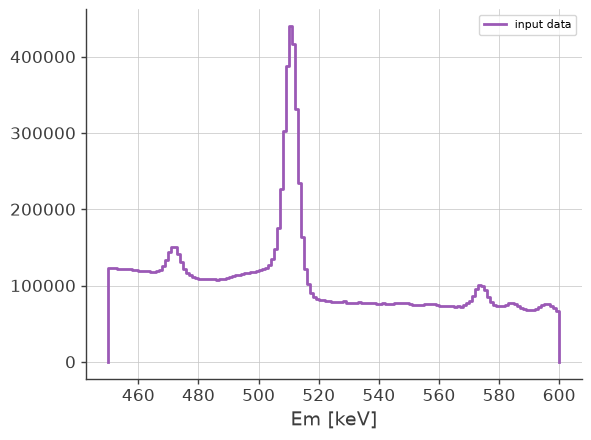

In [18]:
# Exclude exactly the four 1 keV bins spanning 509--513 keV.
# Small offsets prevent COSIpy from also masking the adjacent edge-touching bins.
# fit_exclusion_range = (
#     np.array([509.0 + 1e-6, 513.0 - 1e-6]) * u.keV
# )

line_background_estimator.set_mask()

ax, _ = line_background_estimator.plot_energy_spectrum()
save_background_figure(
    ax.figure,
    "masked_energy_spectrum",
)
plt.show()

#### Background spectral model

In [19]:
def powerlaw(x, a, b, pivot):
    return a * (x / pivot) ** b


def gaussian(x, area, mu, sigma):
    return (
        area
        / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    )


def bkg_model(
    x,
    a,
    b,
    area_474,
    mu_474,
    sigma_474,
    area_511,
    mu_511,
    sigma_511,
    area_575,
    mu_575,
    sigma_575,  
):
    pivot = 511.0

    return (
        powerlaw(x, a, b, pivot)
        + gaussian(x, area_474, mu_474, sigma_474)
        + gaussian(x, area_511, mu_511, sigma_511)
        + gaussian(x, area_575, mu_575, sigma_575)
    )

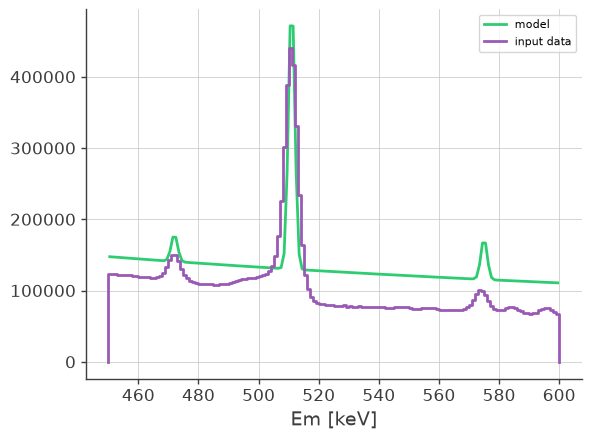

In [20]:
# Initial guesses for the continuum and three instrumental-line components.

initial_line_model_parameters = [
   130000,   # Continuum normalization near 511 keV
    -1,    # Continuum power-law index
    100000,     # Integrated area of the feature near 474 keV
    472.0,     # Center of the first Gaussian in keV
    1,
    1000000,   # Integrated area of the feature near 511 keV
    511,   # Center of the second Gaussian in keV
    1,
    150000,     # Integrated area of the feature near 575 keV
    575.0,     # Center of the third Gaussian in keV
    1,     # Initial shared Gaussian sigma in keV
]

line_background_estimator.set_bkg_energy_spectrum_model(bkg_model,initial_line_model_parameters,)
ax, _ = line_background_estimator.plot_energy_spectrum()
save_background_figure(
    ax.figure,
    "initial_spectral_model",
)
plt.show()

In [21]:
# Constrain only parameters that have physical restrictions.
line_parameter_limits = {
    0: (0.0, None),      # Continuum normalization
    
    2: (0.0, None),      # Area near 474 keV
    3: (470.0, 478.0),   # Center near 474 keV
    4: (0.01, 10.0),      # Shared Gaussian sigma
    
    5: (0.0, None),      # Area near 511 keV
    6: (509.0, 513.0),   # Center near 511 keV
    7: (0.1, 10),      # Area near 575 keV
    
    8: (0.0, None),
    9: (570.0, 580.0),   # Center near 575 keV
    10: (0.01, 10.0),      # Shared Gaussian sigma
}

# # Retry from the parameters saved by the previous attempt, if needed.
# max_fit_attempts = 10

# for fit_attempt in range(1, max_fit_attempts + 1):
#     line_model_fit = line_background_estimator.fit_energy_spectrum(
#         param_limits=line_parameter_limits
#     )

#     if line_model_fit.valid:
#         break
# else:
#     raise RuntimeError(
#         f"The spectral fit did not converge after {max_fit_attempts} attempts."
#     )

# print(f"Fit converged after {fit_attempt} attempt(s).")
# line_model_fit

In [22]:
# Exclude a wider region around the possible 511 keV source contribution,
# then refit using the parameters obtained from the previous fit.

fit_exclusion_range = (
    np.array([509.0 + 1e-6, 513.0 - 1e-6]) * u.keV
)

line_background_estimator.set_mask(
    fit_exclusion_range
)

max_masked_fit_attempts = 10

for masked_fit_attempt in range(1, max_masked_fit_attempts + 1):
    line_model_fit = line_background_estimator.fit_energy_spectrum(
        param_limits=line_parameter_limits
    )

    if line_model_fit.valid:
        break
else:
    raise RuntimeError(
        "The masked spectral fit did not converge after "
        f"{max_masked_fit_attempts} attempts."
    )

print(
    f"Masked fit converged after "
    f"{masked_fit_attempt} attempt(s)."
)

line_model_fit

Masked fit converged after 1 attempt(s).


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.523e+08                 │             Nfcn = 1409              │
│ EDM = 3.32e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │ 94.632e3  │  0.029e3  │            │            │    0    │         │       │
│ 1 │ x1   │  -2.393   │   0.004   │            │            │         │         │       │
│ 2 │ x2   │  190.7e3  │   1.1e3   │            │            │    0    │         │       │
│ 3 │ x3   │  472.035  │   0.016   │            │            │   470   │   478   │       │
│ 4 │ x4   │   2.083   │   0.016   │            │            │  0.01   │   10    │       │
│ 5 │ x5   │ 1.6722e6  │ 0.0027e6  │            │            │    0    │         │       │
│ 6 │ x6   │  510.296  │   0.004   │            │            │   509   │   513   │       │
│ 7 │ x7   │   2.692   │   0.005   │            │            │   0.1   │   10    │       │
│ 8 │ x8   │  156.3e3  │   1.1e3   │            │            │    0    │         │       │
│ 9 │ x9   │  574.033  │   0.016   │            │            │   570   │   580   │       │
│ 10│ x10  │   2.159   │   0.018   │            │            │  0.01   │   10    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│     │          x0          x1          x2          x3          x4          x5          x6          x7          x8          x9         x10 │
├─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│  x0 │         872  -10.552e-3      -9.0e3    -0.40e-3   -74.59e-3      -3.2e3   12.338e-3  -33.701e-3      -5.9e3    -3.25e-3   -65.53e-3 │
│  x1 │  -10.552e-3    1.37e-05    1.321662   -0.001e-3    0.011e-3 -841.534e-3   -0.001e-3    0.001e-3   -1.451048   -0.002e-3   -0.015e-3 │
│  x2 │      -9.0e3    1.321662     1.3e+06   -48.31e-3     9.17420      -0.1e6 -262.983e-3  509.966e-3      -0.2e6  -225.55e-3    -2.00941 │
│  x3 │    -0.40e-3   -0.001e-3   -48.31e-3    0.000243     0.01e-3   785.93e-3           0   -0.001e-3   189.69e-3           0           0 │
│  x4 │   -74.59e-3    0.011e-3     9.17420     0.01e-3    0.000242    -1.48792   -0.002e-3    0.004e-3    -1.55105          -0    -0.01e-3 │
│  x5 │      -3.2e3 -841.534e-3      -0.1e6   785.93e-3    -1.48792    7.09e+06    3.844902   -5.305928       0.6e6   490.86e-3     6.10343 │
│  x6 │   12.338e-3   -0.001e-3 -262.983e-3           0   -0.002e-3    3.844902    1.69e-05   -0.009e-3  302.545e-3           0    0.003e-3 │
│  x7 │  -33.701e-3    0.001e-3  509.966e-3   -0.001e-3    0.004e-3   -5.305928   -0.009e-3    2.42e-05 -274.878e-3          -0   -0.002e-3 │
│  x8 │      -5.9e3   -1.451048      -0.2e6   189.69e-3    -1.55105       0.6e6  302.545e-3 -274.878e-3    1.25e+06   818.08e-3    11.74218 │
│  x9 │    -3.25e-3

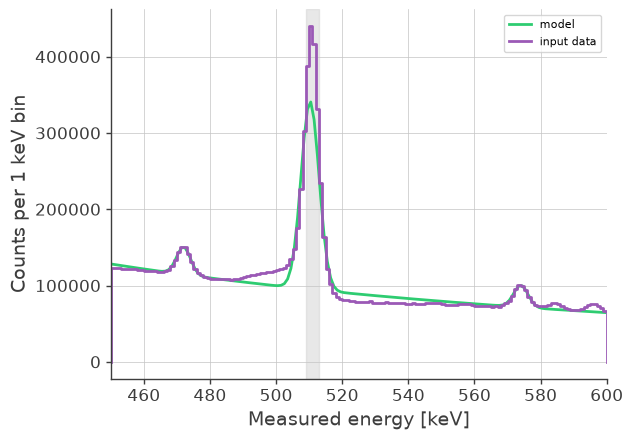

In [23]:
# Plot the fitted continuum-plus-line model over the observed spectrum.
ax, _ = line_background_estimator.plot_energy_spectrum()

ax.set_xlim(450, 600)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")

save_background_figure(
    ax.figure,
    "fitted_spectral_model",
)
plt.show()

### Source window and background sidebands

In [24]:
# Final science window for the 511 keV analysis.

source_energy_range = (
    np.array([509.0, 513.0]) * u.keV
)

# Combined baseline: use every available bin outside the source window.

background_regions = [
    np.array([450.0, 509.0]) * u.keV,
    np.array([513.0, 600.0]) * u.keV,
]

# Far-continuum intervals excluding the visible instrumental features.

continuum_regions = [
    np.array([450.0, 468.0]) * u.keV,
    np.array([480.0, 503.0]) * u.keV,
    np.array([520.0, 568.0]) * u.keV,
]

# Near sidebands used to trace the 511 keV instrumental-line wings.

line_wing_regions = [
    np.array([503.0, 509.0]) * u.keV,
    np.array([513.0, 520.0]) * u.keV,
]

secondary_line_regions = [
    np.array([468.0, 480.0]) * u.keV,
    np.array([568.0, 582.0]) * u.keV,
]

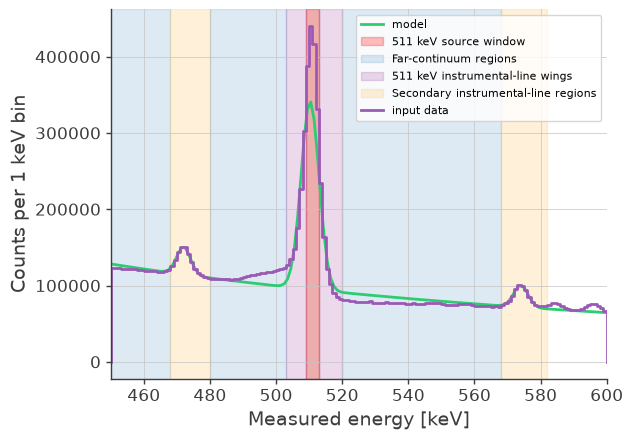

In [25]:
# Visualize the source window and the sidebands used for background estimation.
# Unshaded bins outside the source window belong to the combined baseline.

ax, _ = line_background_estimator.plot_energy_spectrum()

ax.axvspan(
    source_energy_range[0].value,
    source_energy_range[1].value,
    color="red",
    alpha=0.25,
    label="511 keV source window",
)

for index, region in enumerate(continuum_regions):
    ax.axvspan(
        region[0].value,
        region[1].value,
        color="tab:blue",
        alpha=0.15,
        label=(
            "Far-continuum regions"
            if index == 0
            else None
        ),
    )

for index, region in enumerate(line_wing_regions):
    ax.axvspan(
        region[0].value,
        region[1].value,
        color="purple",
        alpha=0.15,
        label=(
            "511 keV instrumental-line wings"
            if index == 0
            else None
        ),
    )
for index, region in enumerate(secondary_line_regions):
    ax.axvspan(
        region[0].value,
        region[1].value,
        color="orange",
        alpha=0.15,
        label=(
            "Secondary instrumental-line regions"
            if index == 0
            else None
        ),
    )

ax.set_xlim(
    background_energy_bin_edges[0],
    background_energy_bin_edges[-1],
)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")
ax.legend()

save_background_figure(
    ax.figure,
    "energy_sideband_windows",
)

plt.show()

### Background variants

Five spatial-processing variants are generated for the combined baseline and separately for the far-continuum and instrumental-line-wing sidebands:

- `raw`: the unfiltered sideband template.
- `smoothing`: Gaussian angular smoothing with a 20 degree FWHM.
- `l_cut`: harmonic filtering that retains multipoles through `l = 4`.
- `rebin+smoothing`: temporary grouping of 10 `Phi` bins before smoothing.
- `rebin+l_cut`: temporary grouping of 10 `Phi` bins before harmonic filtering.

These are not different spectral fits. Within each sideband family, they share the fitted spectral model and differ only in how the spatial template is filtered. The combined baseline and the two separated raw estimates are compared directly with the simulated background below.


In [26]:
# Define the spatial-processing settings for each background model.
background_model_settings = {
    "raw": {},

    "smoothing": {
        "smoothing_fwhm": 20 * u.deg,
    },

    "l_cut": {
        "l_cut": 4,
    },

    "rebin_smoothing": {
        "rebin_phi": 10,
        "smoothing_fwhm": 20 * u.deg,
    },
    
    "rebin_l_cut": {
        "rebin_phi": 10,
        "l_cut": 4,
    },
}


In [27]:
# Generate all candidate background models and keep them in memory.

combined_models_511 = {}
continuum_models_511 = {}
line_wing_models_511 = {}

for name, settings in background_model_settings.items():
    combined_models_511[name] = (
        line_background_estimator.generate_bkg_model_histogram(
            source_energy_range=source_energy_range,
            bkg_estimation_energy_ranges=background_regions,
            **settings,
        )
    )

    continuum_models_511[name] = (
        line_background_estimator.generate_bkg_model_histogram(
            source_energy_range=source_energy_range,
            bkg_estimation_energy_ranges=continuum_regions,
            **settings,
        )
    )

    line_wing_models_511[name] = (
        line_background_estimator.generate_bkg_model_histogram(
            source_energy_range=source_energy_range,
            bkg_estimation_energy_ranges=line_wing_regions,
            **settings,
        )
    )

# Keep all three raw sideband estimates together for direct validation.

diagnostic_background_models = {
    "combined_baseline": combined_models_511["raw"],
    "far_continuum": continuum_models_511["raw"],
    "line_wings": line_wing_models_511["raw"],
}

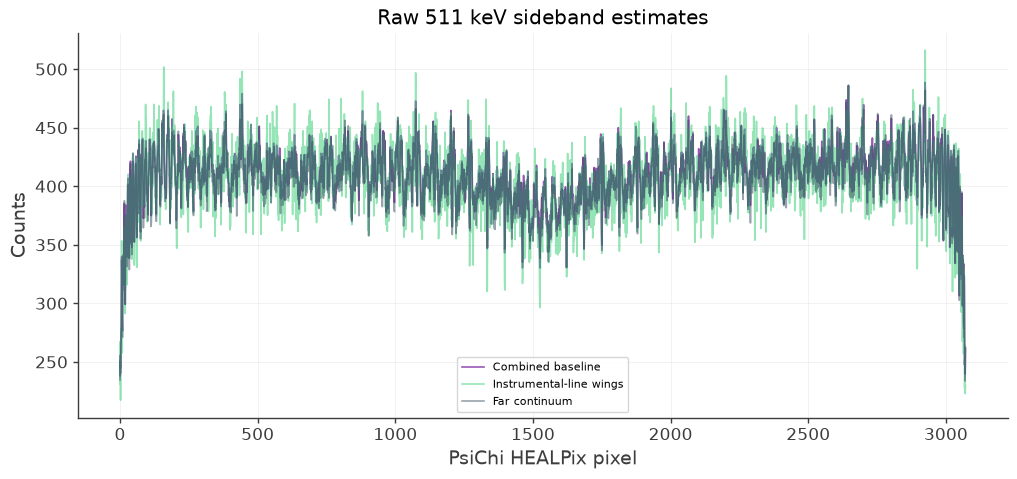

In [28]:
# Compare all three raw sideband estimates in one PsiChi projection.
fig, ax = plt.subplots(figsize=(12, 5))


psichi_projection_combined = (
            combined_models_511["raw"]
            .project("PsiChi")
            .to_dense(copy=False)
            )
psichi_projection_con = (
            continuum_models_511["raw"]
            .project("PsiChi")
            .to_dense(copy=False)
            )
psichi_projection_lin = (
            line_wing_models_511["raw"]
            .project("PsiChi")
            .to_dense(copy=False)
            )

values0 = np.asarray(psichi_projection_combined.contents)
values1 = np.asarray(psichi_projection_con.contents)
values2 = np.asarray(psichi_projection_lin.contents)
pixels0 = np.arange(values0.size)
pixels1 = np.arange(values1.size)
pixels2 = np.arange(values2.size)


ax.plot(
        pixels0,
        values0,
        label="Combined baseline",
        linewidth=1.2,
    )
ax.plot(
        pixels2,
        values2,
        label="Instrumental-line wings",
        linewidth=1.2,
        alpha=0.5,
    )
ax.plot(
        pixels1,
        values1,
        label="Far continuum",
        linewidth=1.2,
        alpha=0.5,
    )



ax.set_xlabel("PsiChi HEALPix pixel")
ax.set_ylabel("Counts")
ax.set_title("Raw 511 keV sideband estimates")
ax.legend()
ax.grid(alpha=0.3)

save_background_figure(
    fig,
    "raw_psichi_sideband_estimates",
)
plt.show()

## Validation with simulated background

1. Bin and load the provided simulated total background in the 509–513 keV window.
2. Compare its normalization with the combined baseline and the two separated raw estimates.
3. Compare the `Phi` distributions and residuals.
4. Compare the `PsiChi` distributions and residuals.

No model should be selected for the imaging analysis until these comparisons are complete.

### Binning the simulated background if not done yet

In [29]:
# Create the BinnedData object using the final 509--513 keV binning.
simulated_background_analysis = cp.BinnedData(
    paths.config_511_path
)

# Bin the simulated background only if the output is missing.
if not paths.simulated_background_511_binned_path.exists():
    simulated_background_analysis.get_binned_data(
        unbinned_data=str(paths.simulated_background_path),
        output_name=str(
            paths.simulated_background_511_binned_path.with_suffix("")
        ),
    )

# Load the existing or newly generated histogram.
simulated_background_analysis.load_binned_data_from_hdf5(
    binned_data=str(
        paths.simulated_background_511_binned_path
    )
)
simulated_background_analysis.get_binning_info()

# Sum over time while preserving Em, Phi, and PsiChi.
simulated_background_511 = (
    simulated_background_analysis
    .binned_data
    .project("Em", "Phi", "PsiChi")
)

# Verify compatibility with the estimated background models.

print("Shape:", simulated_background_511.shape)
print("Axes:", simulated_background_511.axes.labels)
print(
    "Energy edges:",
    simulated_background_511.axes["Em"].edges,
)

Shape: (1, 60, 3072)
Axes: ['Em' 'Phi' 'PsiChi']
Energy edges: [509. 513.] keV


### Visualization and validation against the simulation

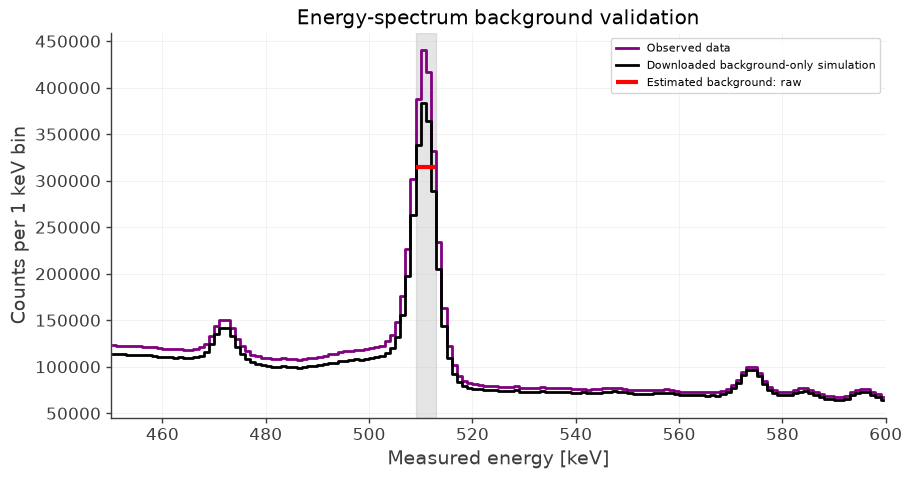

In [30]:
# Validate the observed spectrum and the raw background estimate
# against the downloaded background-only simulation.

observed_energy_spectrum = (
    background_hist_all
    .project("Em")
    .to_dense(copy=False)
)

with fits.open(
    simulated_background_path,
) as hdul:
    simulated_background_energy_counts, _ = np.histogram(
        hdul[1].data["Energies"],
        bins=background_energy_bin_edges,
    )

energy_centers = 0.5 * (
    background_energy_bin_edges[:-1]
    + background_energy_bin_edges[1:]
)

# The raw model contains one integrated 509--513 keV energy bin.
raw_background_counts = float(
    np.sum(
        combined_models_511["raw"]
        .to_dense(copy=False)
        .contents
    )
)

source_width = (
    source_energy_range[1] - source_energy_range[0]
).to_value(u.keV)

raw_background_counts_per_keV = (
    raw_background_counts / source_width
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.step(
    energy_centers,
    observed_energy_spectrum.contents,
    where="mid",
    color="purple",
    label="Observed data",
)

ax.step(
    energy_centers,
    simulated_background_energy_counts,
    where="mid",
    color="black",
    label="Downloaded background-only simulation",
)

ax.hlines(
    raw_background_counts_per_keV,
    source_energy_range[0].value,
    source_energy_range[1].value,
    color="red",
    linewidth=3,
    label="Estimated background: raw",
)

ax.axvspan(
    source_energy_range[0].value,
    source_energy_range[1].value,
    color="grey",
    alpha=0.2,
)

ax.set_xlim(450, 600)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")
ax.set_title("Energy-spectrum background validation")
ax.legend()
ax.grid(alpha=0.3)

save_background_figure(
    fig,
    "energy_spectrum_background_validation",
)
plt.show()

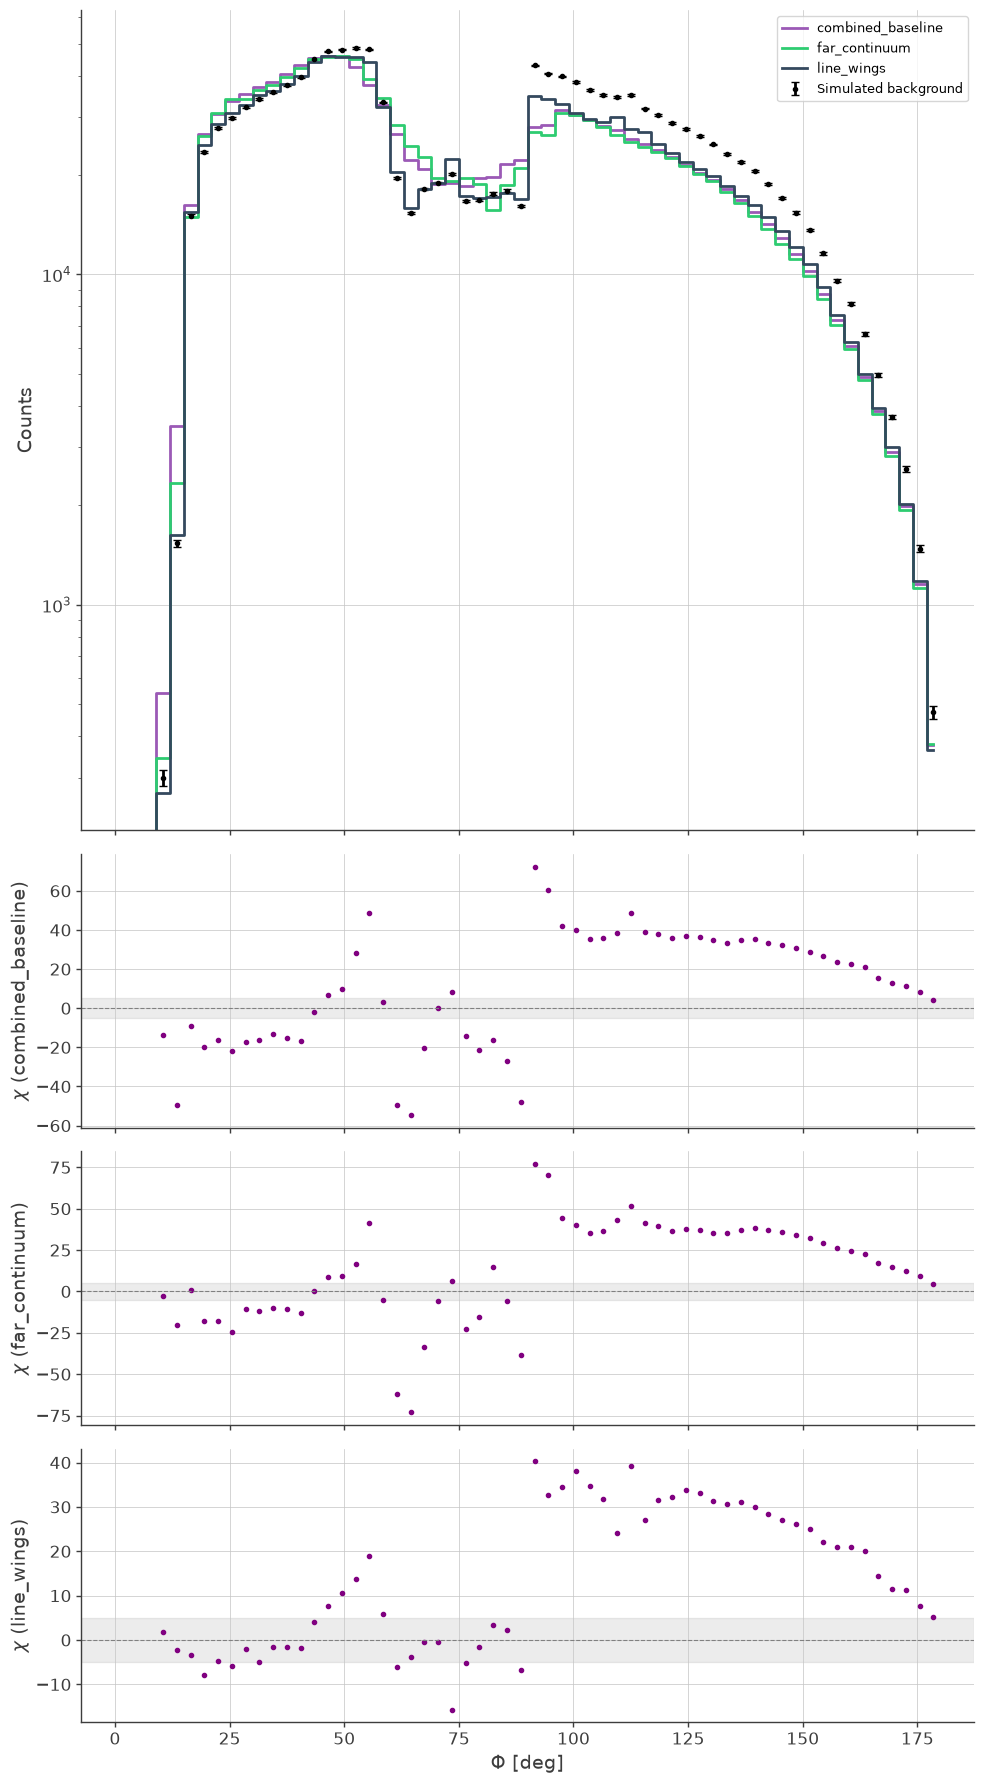

In [31]:
# Project the simulated background onto Phi.
phi_simulated = (
    simulated_background_511
    .project("Phi")
    .to_dense(copy=False)
)

phi_centers = (
    phi_simulated.axes["Phi"].centers
)

fig, axes = plt.subplots(
    len(diagnostic_background_models) + 1,
    1,
    figsize=(10, 18),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3]
        + [1] * len(diagnostic_background_models)
    },
)

# Plot the simulated background and every estimated model.
axes[0].errorbar(
    phi_centers,
    phi_simulated.contents,
    yerr=np.sqrt(phi_simulated.contents),
    fmt=".",
    color="black",
    label="Simulated background",
    capsize=3,
)

for name, model in diagnostic_background_models.items():
    phi_model = (
        model
        .project("Phi")
        .to_dense(copy=False)
    )

    axes[0].step(
        phi_centers,
        phi_model.contents,
        where="mid",
        label=name,
    )

axes[0].set_ylabel("Counts")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid()

# Plot standardized residuals for each model.
for ax, (name, model) in zip(
    axes[1:],
    diagnostic_background_models.items(),
):
    phi_model = (
        model
        .project("Phi")
        .to_dense(copy=False)
    )

    # Exclude empty simulated bins from standardized residuals.
    valid_bins = phi_simulated.contents > 0
    residual = (
        phi_simulated.contents[valid_bins]
        - phi_model.contents[valid_bins]
    ) / np.sqrt(phi_simulated.contents[valid_bins])

    ax.plot(
        phi_centers[valid_bins],
        residual,
        ".",
        color="purple",
    )
    ax.axhline(
        0,
        color="grey",
        linestyle="--",
        linewidth=0.8,
    )
    ax.axhspan(
        -5,
        5,
        color="grey",
        alpha=0.15,
    )
    ax.set_ylabel(fr"$\chi$ ({name})")
   
    ax.grid()

axes[-1].set_xlabel(r"$\Phi$ [deg]")

plt.tight_layout()
save_background_figure(
    fig,
    "phi_counts_residuals",
)
plt.show()

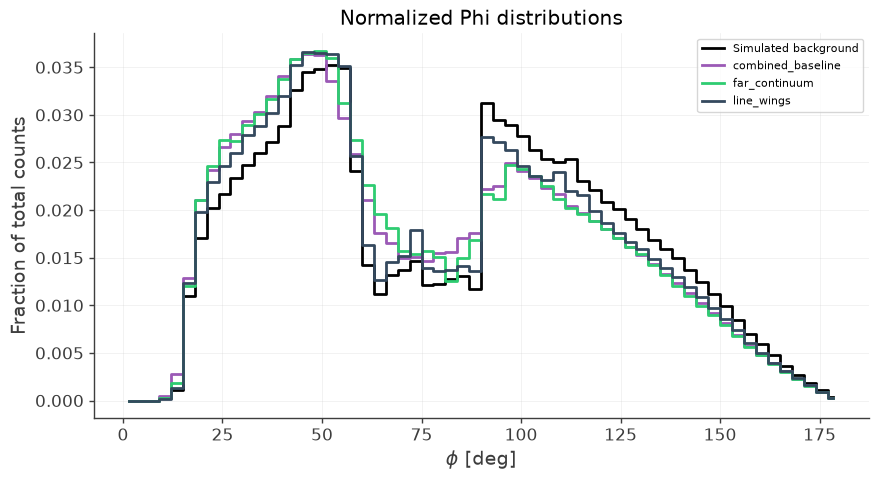

In [32]:
# Normalize the simulated Phi distribution to unit area.
phi_simulated_values = np.asarray(
    phi_simulated.contents,
    dtype=float,
)
phi_simulated_normalized = (
    phi_simulated_values
    / phi_simulated_values.sum()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.step(
    phi_centers,
    phi_simulated_normalized,
    where="mid",
    color="black",
    label="Simulated background",
)

# Normalize and compare every estimated model.
for name, model in diagnostic_background_models.items():
    phi_model = (
        model
        .project("Phi")
        .to_dense(copy=False)
    )

    model_values = np.asarray(
        phi_model.contents,
        dtype=float,
    )
    model_normalized = model_values / model_values.sum()

    ax.step(
        phi_centers,
        model_normalized,
        where="mid",
        label=name,
    )

ax.set_xlabel(r"$\phi$ [deg]")
ax.set_ylabel("Fraction of total counts")
ax.set_title("Normalized Phi distributions")
ax.legend()
ax.grid(alpha=0.3)

save_background_figure(
    fig,
    "phi_normalized",
)
plt.show()

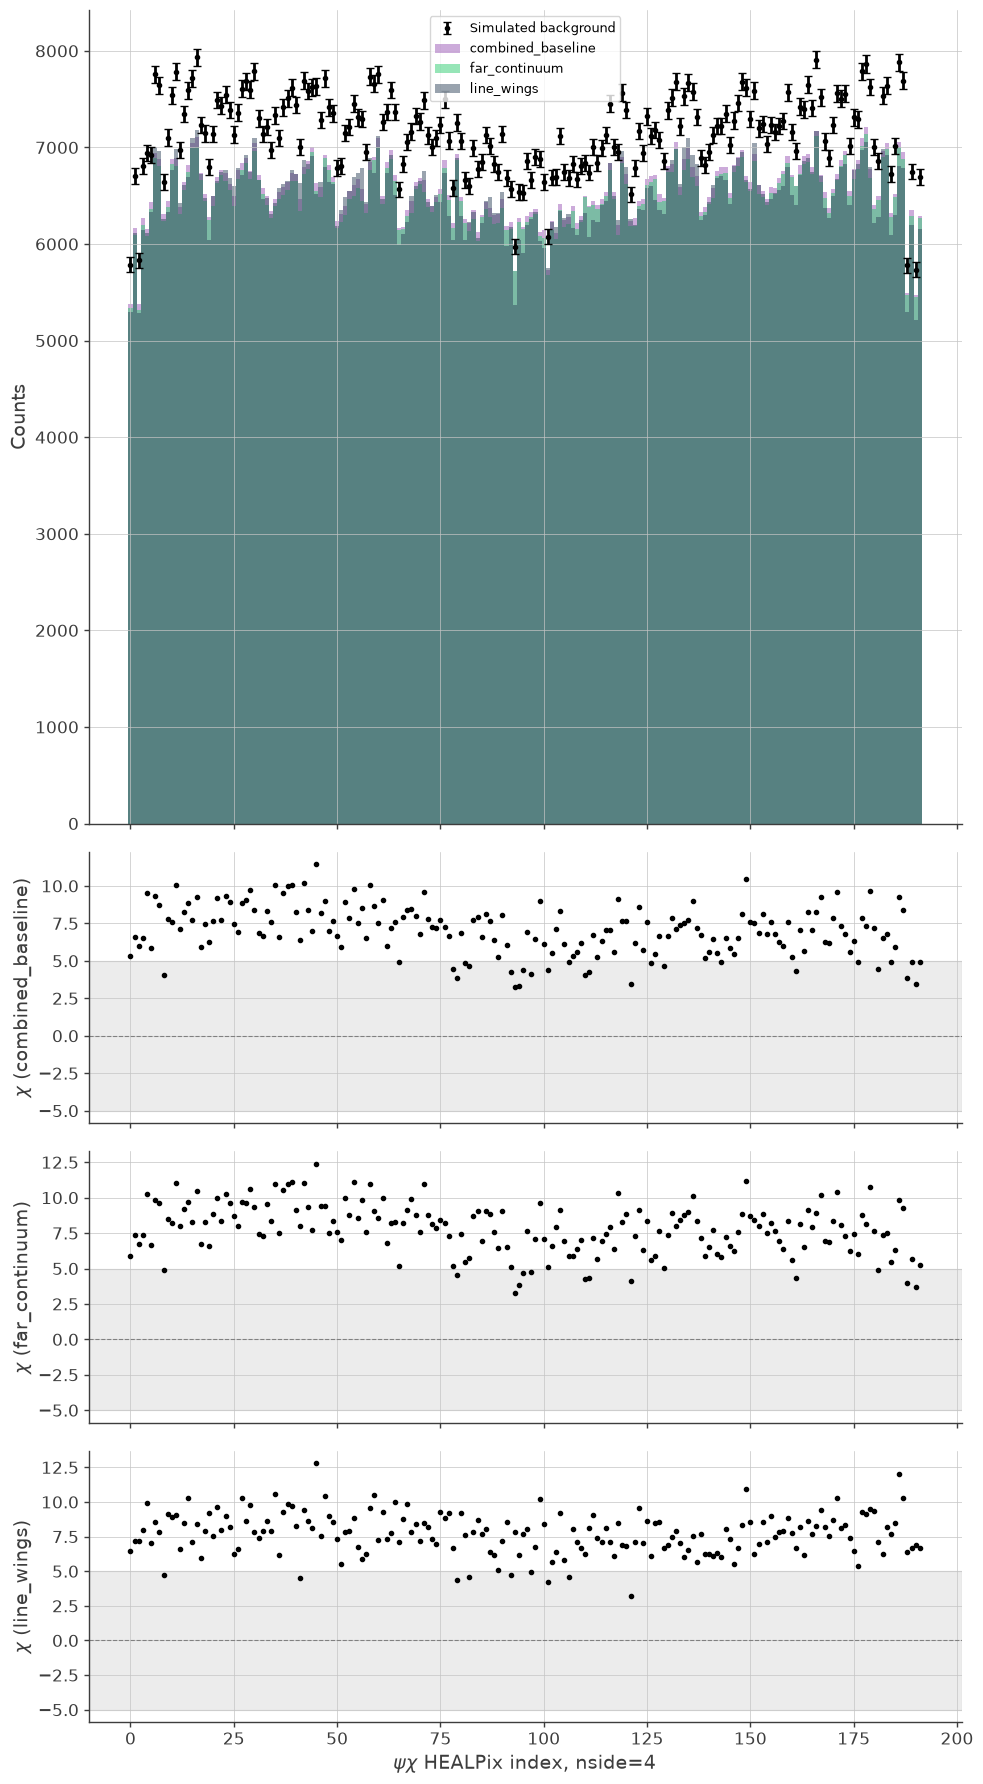

In [33]:
# Degrade the PsiChi distributions to nside=4 for comparison.
nside_out = 4

psichi_simulated = (
    simulated_background_511
    .project("PsiChi")
    .to_dense(copy=False)
)

psichi_simulated_rebinned = hp.ud_grade(
    psichi_simulated[:],
    nside_out,
    power=-2,
)

pixels = np.arange(
    hp.nside2npix(nside_out)
)

fig, axes = plt.subplots(
    len(diagnostic_background_models) + 1,
    1,
    figsize=(10, 18),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3]
        + [1] * len(diagnostic_background_models)
    },
)

# Compare the simulated background with all estimated models.
axes[0].errorbar(
    pixels,
    psichi_simulated_rebinned,
    yerr=np.sqrt(psichi_simulated_rebinned),
    fmt=".",
    color="black",
    label="Simulated background",
    capsize=3,
)

for name, model in diagnostic_background_models.items():
    psichi_model = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    psichi_model_rebinned = hp.ud_grade(
        psichi_model[:],
        nside_out,
        power=-2,
    )

    axes[0].bar(
        pixels,
        psichi_model_rebinned,
        width=1,
        alpha=0.5,
        label=name,
    )

axes[0].set_ylabel("Counts")
axes[0].legend(fontsize=9)
axes[0].grid()

# Plot standardized residuals.
for ax, (name, model) in zip(
    axes[1:],
    diagnostic_background_models.items(),
):
    psichi_model = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    psichi_model_rebinned = hp.ud_grade(
        psichi_model[:],
        nside_out,
        power=-2,
    )

    # Exclude empty simulated pixels from standardized residuals.
    valid_pixels = psichi_simulated_rebinned > 0
    residual = (
        psichi_simulated_rebinned[valid_pixels]
        - psichi_model_rebinned[valid_pixels]
    ) / np.sqrt(psichi_simulated_rebinned[valid_pixels])

    ax.plot(
        pixels[valid_pixels],
        residual,
        ".",
        color="black",
    )
    ax.axhline(
        0,
        color="grey",
        linestyle="--",
        linewidth=0.8,
    )
    ax.axhspan(
        -5,
        5,
        color="grey",
        alpha=0.15,
    )
    ax.set_ylabel(fr"$\chi$ ({name})")
   
    ax.grid()

axes[-1].set_xlabel(
    rf"$\psi\chi$ HEALPix index, nside={nside_out}"
)

plt.tight_layout()
save_background_figure(
    fig,
    "psichi_counts_residuals_nside4",
)
plt.show()

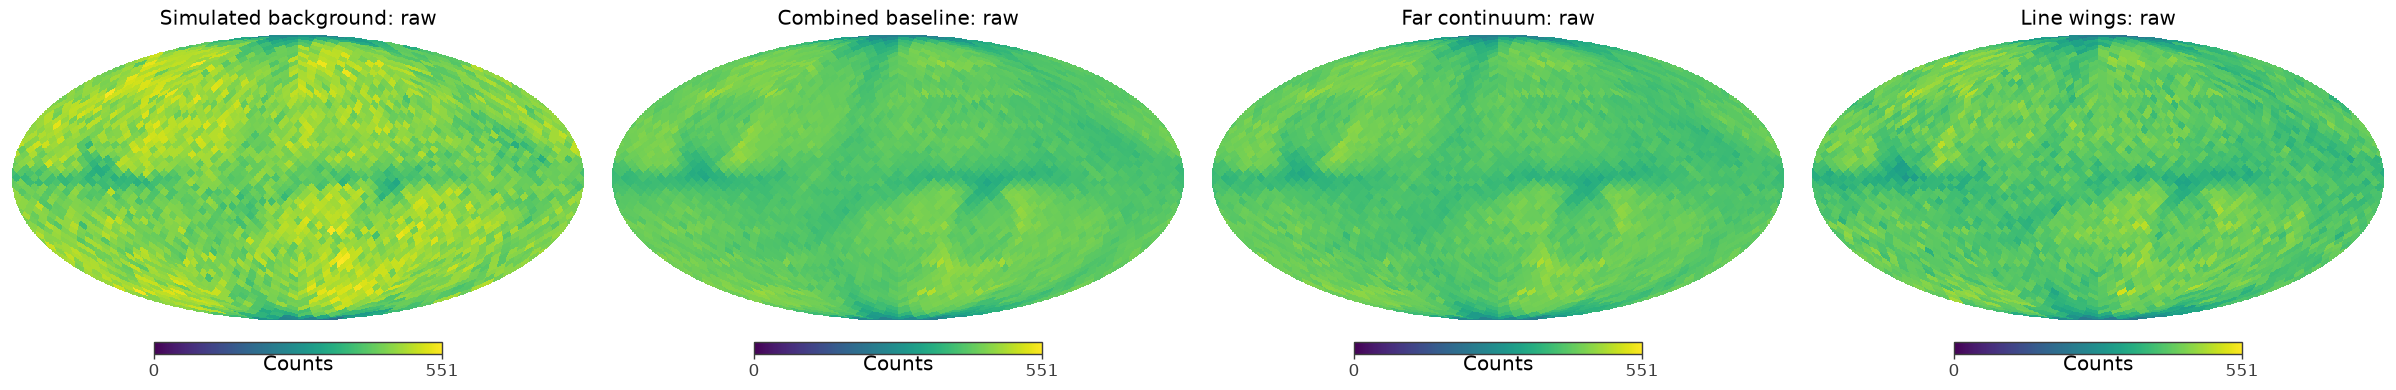

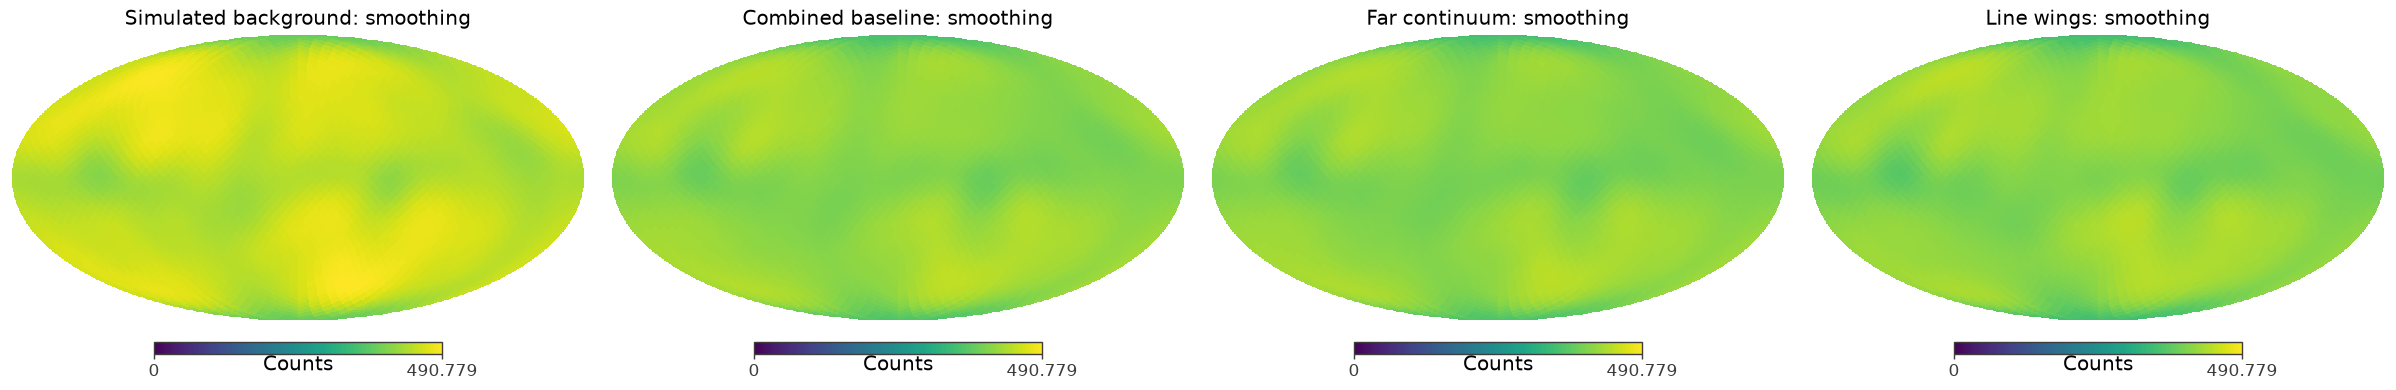

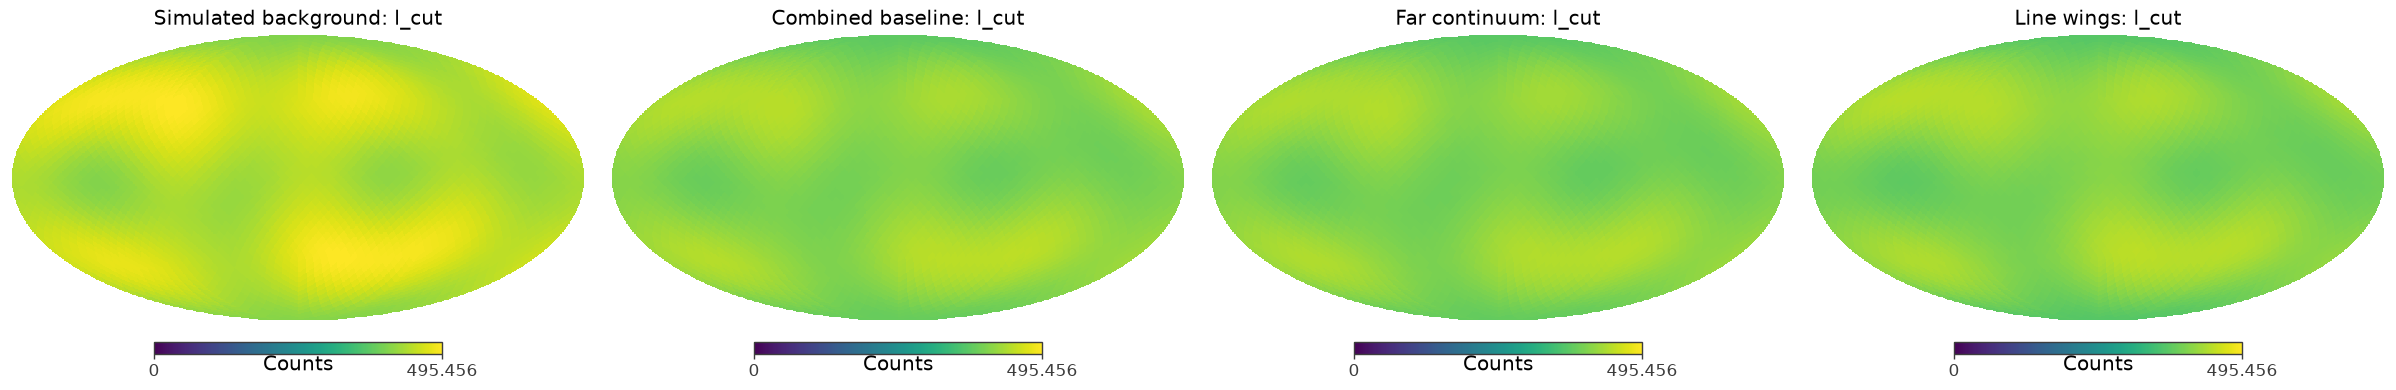

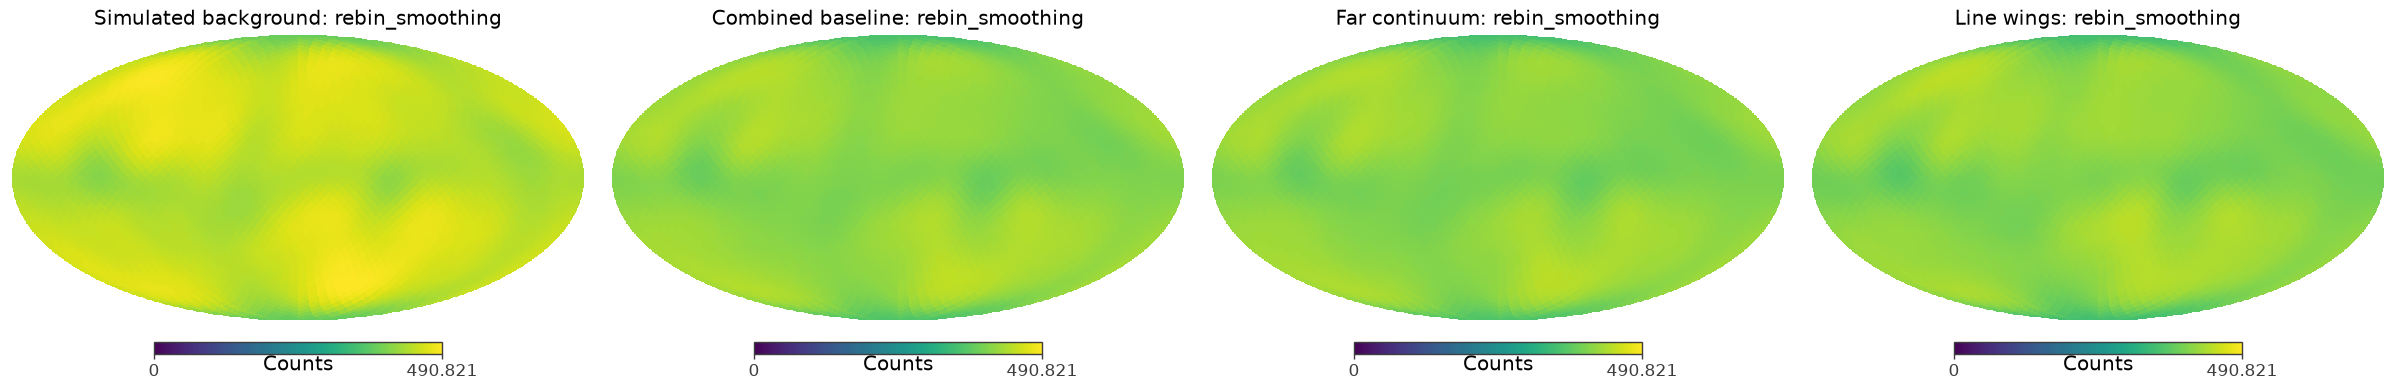

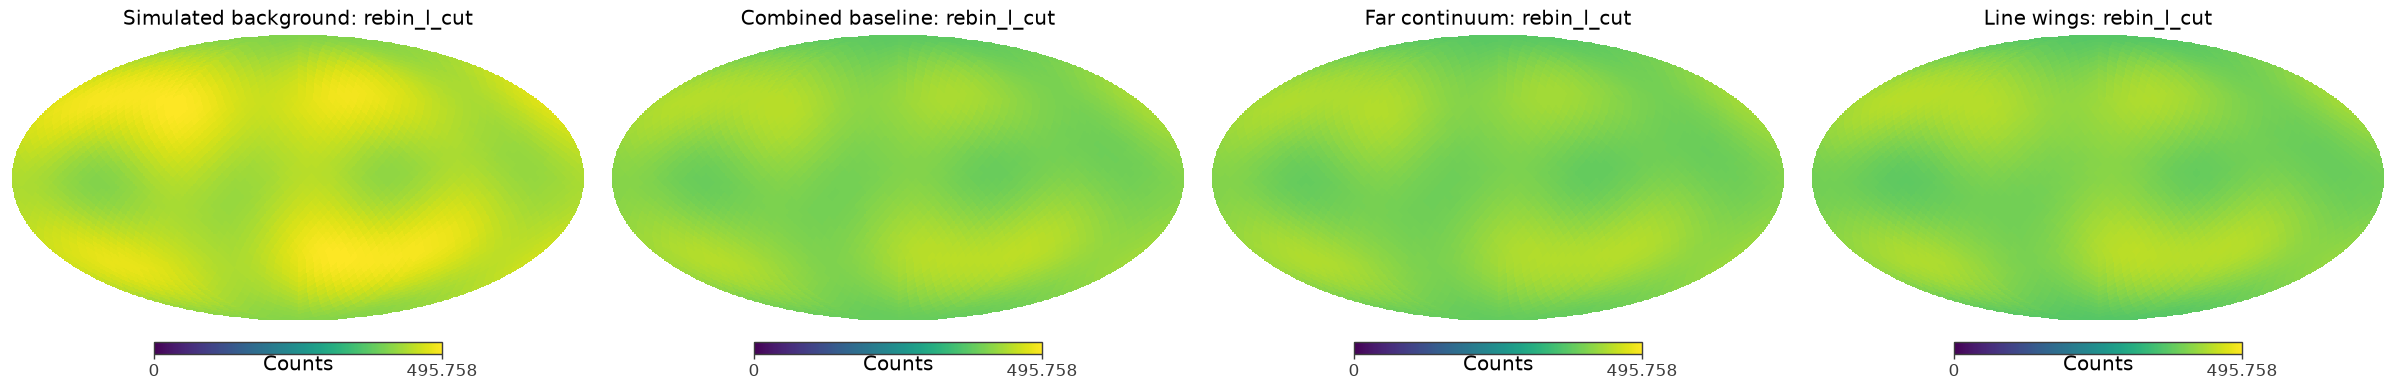

In [34]:
# Apply the same spatial-processing methods to the simulated background.
simulated_background_arrays = {}
simulated_background_raw = np.asarray(
    simulated_background_511.to_dense(copy=False).contents,
    dtype=float,
)

for method, settings in background_model_settings.items():
    simulated_values = simulated_background_raw.copy()
    smoothing_fwhm = settings.get("smoothing_fwhm")
    l_cut = settings.get("l_cut")
    rebin_phi = settings.get("rebin_phi")

    if smoothing_fwhm is not None or l_cut is not None:
        if rebin_phi is not None:
            rebinned, n_groups, phi_axis_idx = (
                line_background_estimator._rebin_phi(
                    simulated_values,
                    rebin_phi,
                )
            )
            rebinned = line_background_estimator._apply_spatial_filter(
                rebinned,
                simulated_background_511.axes,
                smoothing_fwhm,
                l_cut,
            )
            simulated_values = line_background_estimator._unbin_phi(
                simulated_values,
                rebinned,
                n_groups,
                rebin_phi,
                phi_axis_idx,
            )
        else:
            simulated_values = (
                line_background_estimator._apply_spatial_filter(
                    simulated_values,
                    simulated_background_511.axes,
                    smoothing_fwhm,
                    l_cut,
                )
            )

    simulated_background_arrays[method] = simulated_values

# Create one four-panel PsiChi comparison for each processing method.
for method in background_model_settings:
    psichi_maps = {
        "Simulated background": simulated_background_arrays[method].sum(
            axis=(0, 1)
        ),
        "Combined baseline": np.asarray(
            combined_models_511[method]
            .project("PsiChi")
            .to_dense(copy=False)
            .contents
        ),
        "Far continuum": np.asarray(
            continuum_models_511[method]
            .project("PsiChi")
            .to_dense(copy=False)
            .contents
        ),
        "Line wings": np.asarray(
            line_wing_models_511[method]
            .project("PsiChi")
            .to_dense(copy=False)
            .contents
        ),
    }

    common_max = max(values.max() for values in psichi_maps.values())
    fig = plt.figure(figsize=(24, 4))

    for panel, (name, values) in enumerate(psichi_maps.items(), start=1):
        hp.mollview(
            values,
            title=f"{name}: {method}",
            fig=fig.number,
            sub=(1, 4, panel),
            unit="Counts",
            min=0.0,
            max=common_max,
        )

    save_background_figure(
        fig,
        f"psichi_method_comparison_{method}",
    )
    plt.show()

## Background: Simulated & data-driven diagnostics

In [35]:
# First verify that the observed and simulated datasets cover comparable
# time spans before comparing their total numbers of events.

weekly_time_ranges = {}

for week, input_path in paths.weekly_paths.items():
    with fits.open(input_path, memmap=True) as hdul:
        time_tags = hdul[1].data["TimeTags"]

        weekly_time_ranges[week] = (
            float(time_tags[0]),
            float(time_tags[-1]),
        )

observed_start = min(
    time_range[0]
    for time_range in weekly_time_ranges.values()
)
observed_stop = max(
    time_range[1]
    for time_range in weekly_time_ranges.values()
)

with fits.open(
    simulated_background_path,
    memmap=True,
) as hdul:
    simulated_time_tags = hdul[1].data["TimeTags"]

    simulated_start = float(simulated_time_tags[0])
    simulated_stop = float(simulated_time_tags[-1])

seconds_per_day = 86400.0

print(
    "Observed time range:",
    observed_start,
    observed_stop,
)
print(
    "Observed span [days]:",
    (observed_stop - observed_start) / seconds_per_day,
)
print(
    "Simulated time range:",
    simulated_start,
    simulated_stop,
)
print(
    "Simulated span [days]:",
    (simulated_stop - simulated_start) / seconds_per_day,
)

Observed time range: 1835487300.036206 1843467254.887687
Observed span [days]: 92.36058855880742
Simulated time range: 1835487401.2760663 1843372211.2617948
Simulated span [days]: 91.25937483482063


In [36]:
# Next compare the total counts in the 509--513 keV analysis window.
# The observed data contain source plus background, whereas the simulation
# and raw estimate describe background only.

source_bin_mask = (
    (energy_centers >= source_energy_range[0].to_value(u.keV))
    & (energy_centers < source_energy_range[1].to_value(u.keV))
)

observed_source_window_counts = float(
    np.sum(observed_energy_spectrum.contents[source_bin_mask])
)

simulated_source_window_counts = float(
    np.sum(simulated_background_energy_counts[source_bin_mask])
)

raw_source_window_counts = raw_background_counts

raw_difference_percent = (
    raw_source_window_counts
    / simulated_source_window_counts
    - 1.0
) * 100.0

observed_excess_counts = (
    observed_source_window_counts
    - simulated_source_window_counts
)

print(f"Observed data:        {observed_source_window_counts:,.1f}")
print(f"Simulated background: {simulated_source_window_counts:,.1f}")
print(f"Estimated raw model:  {raw_source_window_counts:,.1f}")
print(f"Raw model difference: {raw_difference_percent:+.2f}%")
print(f"Observed excess:      {observed_excess_counts:,.1f}")

Observed data:        1,576,953.0
Simulated background: 1,374,985.0
Estimated raw model:  1,260,216.6
Raw model difference: -8.35%
Observed excess:      201,968.0


In [37]:
# Finally compare only the PsiChi shapes of the three raw estimates with
# the simulated background. Each estimate is normalized to the simulated
# total first, so the residual statistics test morphology rather than yield.

simulated_values = np.asarray(
    simulated_background_511
    .project("PsiChi")
    .to_dense(copy=False)
    .contents,
    dtype=float,
)

for name, model in diagnostic_background_models.items():
    model_values = np.asarray(
        model
        .project("PsiChi")
        .to_dense(copy=False)
        .contents,
        dtype=float,
    )

    normalization = simulated_values.sum() / model_values.sum()
    scaled_model_values = normalization * model_values

    # Empty simulated bins have no defined standardized residual.
    valid_bins = simulated_values > 0
    residual = (
        simulated_values[valid_bins] - scaled_model_values[valid_bins]
    ) / np.sqrt(simulated_values[valid_bins])

    print(
        f"{name:20s} "
        f"scale = {normalization:.4f}, "
        f"mean chi = {residual.mean():+.3f}, "
        f"rms chi = {np.sqrt(np.mean(residual**2)):.3f}"
    )

combined_baseline    scale = 1.0911, mean chi = -0.031, rms chi = 1.086
far_continuum        scale = 1.1024, mean chi = -0.031, rms chi = 1.124
line_wings           scale = 1.1007, mean chi = -0.026, rms chi = 1.326


In [38]:
# Save "best" background model 
selected_background_model_511 = combined_models_511["raw"]

In [39]:
selected_background_model_path = (
    paths.data_dir_out
    / "background_model_511_combined_baseline_raw.hdf5"
)

selected_background_model_511.write(
    str(selected_background_model_path),
    overwrite=True,
)

print(f"Saved selected background model to: {selected_background_model_path}")
print("Shape:", selected_background_model_511.shape)
print("Axes:", selected_background_model_511.axes.labels)

Saved selected background model to: /Users/maura/Documents/COSI/data-challenge-4/workflow/data/outputs/background_model_511_combined_baseline_raw.hdf5
Shape: (1, 60, 3072)
Axes: ['Em' 'Phi' 'PsiChi']


### Auxiliary energy-binning comparison

Both configurations use 1 keV measured-energy bins and retain the same final 509–513 keV science window. The wider auxiliary range changes only the spectral fit and the sidebands used to estimate that final-window background.

| Quantity | First type of binning | Second type of  binning |
|---|---:|---:|
| Auxiliary energy range | 480–540 keV | 480–560 keV |
| Number of energy bins | 60 | 80 |
| Auxiliary histogram shape | `(60, 60, 3072)` | `(80, 60, 3072)` |
| Combined-baseline sidebands | 480–509 and 513–540 keV | 480–509 and 513–560 keV |
| Far-continuum sidebands | 480–503 and 520–540 keV | 480–503 and 520–560 keV |
| Line-wing sidebands | 503–509 and 513–520 keV | 503–509 and 513–520 keV |
| Continuum normalization `x0` | 93.69e3 | 95.40e3 |
| Continuum index `x1` | -4.314 | -3.609 |
| Gaussian area `x2` | 1.6913e6 | 1.6763e6 |
| Gaussian center `x3` | 510.346 keV | 510.344 keV |
| Gaussian sigma `x4` | 2.683 keV | 2.638 keV |
| Combined raw background | 1,272,399.9 counts | 1,283,133.4 counts |
| Combined raw bias vs simulation | -7.46% | -6.68% |
| Combined scale / RMS chi | 1.0806 / 1.132 | 1.0716 / 1.119 |
| Far-continuum scale / RMS chi | 1.0788 / 1.193 | 1.0694 / 1.161 |
| Line-wings scale / RMS chi | 1.0844 / 1.326 | 1.0779 / 1.326 |
